In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

sns.set_style("whitegrid")

In [56]:
df = pd.read_csv("resep_bersih.csv")

df.head()

,Title,Ingredients,Steps,Loves,URL,Category,Title Cleaned,Total Ingredients,Ingredients Cleaned,Total Steps,ingredients_join,ingredients_final,Ingredients Final
0,Ayam Woku Manado,1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...,1) Cuci bersih ayam dan tiriskan. Lalu peras j...,1,https://cookpad.com/id/resep/4473027-ayam-woku...,ayam,ayam woku manado,14,"['garam', 'cabe rawit', 'penyedap rasa', 'jeru...",7,garam cabai_rawit penyedap rasa jeruk_nipis ku...,garam cabai rawit penyedap rasa jeruk nipis ku...,"['garam', 'cabai rawit', 'penyedap rasa', 'jer..."
1,Ayam goreng tulang lunak,1 kg ayam (dipotong sesuai selera jangan kecil...,"1) Haluskan bumbu2nya (BaPut, ketumbar, kemiri...",1,https://cookpad.com/id/resep/4471956-ayam-gore...,ayam,ayam goreng tulang lunak,11,"['garam', 'serai', 'minyak', 'air', 'kemiri', ...",5,garam serai minyakk air kemiri daun_jeruk ketu...,garam serai minyak air kemiri daun jeruk ketum...,"['garam', 'serai', 'minyakk', 'air', 'kemiri',..."
2,Ayam cabai kawin,1/4 kg ayam--3 buah cabai hijau besar--7 buah ...,1) Panaskan minyak di dalam wajan. Setelah min...,2,https://cookpad.com/id/resep/4473057-ayam-caba...,ayam,ayam cabai kawin,10,"['garam', 'cabai merah', 'cabai hijau', 'gula'...",3,garam cabai_merah cabai_hijau gula bawang_mera...,garam cabai merah hijau gula bawang minyak air...,"['garam', 'cabai merah', 'cabai hijau', 'gula'..."
3,Ayam Geprek,250 gr daging ayam (saya pakai fillet)--Secuku...,1) Goreng ayam seperti ayam krispi\n2) Ulek se...,10,https://cookpad.com/id/resep/4473023-ayam-geprek,ayam,ayam geprek,7,"['daging ayam', 'kol', 'sambal korek', 'gula',...",3,daging_ayam kol sambal korek gula cabai lalapa...,daging ayam kol sambal korek gula cabai lalapa...,"['daging ayam', 'kol', 'sambal korek', 'gula',..."
4,Minyak Ayam,400 gr kulit ayam & lemaknya--8 siung bawang p...,1) Cuci bersih kulit ayam. Sisihkan\n2) Ambil ...,4,https://cookpad.com/id/resep/4427438-minyak-ayam,ayam,minyak ayam,5,"['kulit ayam', 'ketumbar bubuk', 'geprek', 'ci...",6,kulit ayam ketumbar bubuk geprek cincang kasar...,ayam ketumbar jahe minyak bawang putih,"['kulit ayam', 'ketumbar bubuk', 'geprek', 'ci..."


In [57]:
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Baris : 14938
Jumlah Kolom : 13


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14938 entries, 0 to 14937
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Title                14938 non-null  str  
 1   Ingredients          14938 non-null  str  
 2   Steps                14938 non-null  str  
 3   Loves                14938 non-null  int64
 4   URL                  14938 non-null  str  
 5   Category             14938 non-null  str  
 6   Title Cleaned        14938 non-null  str  
 7   Total Ingredients    14938 non-null  int64
 8   Ingredients Cleaned  14938 non-null  str  
 9   Total Steps          14938 non-null  int64
 10  ingredients_join     14938 non-null  str  
 11  ingredients_final    14938 non-null  str  
 12  Ingredients Final    14938 non-null  str  
dtypes: int64(3), str(10)
memory usage: 1.5 MB


In [59]:
df.describe()

,Loves,Total Ingredients,Total Steps
count,14938.000000,14938.000000,14938.000000
mean,11.856072,12.320056,5.388338
std,21.796171,5.013437,2.256384
min,0.000000,1.000000,1.000000
25%,3.000000,9.000000,4.000000
50%,6.000000,12.000000,5.000000
75%,11.000000,15.000000,7.000000
max,939.000000,77.000000,26.000000


Dataset terdiri dari xxxx resep masakan Indonesia dengan xx fitur yang berisi informasi judul resep, kategori, bahan, langkah memasak, dan tingkat popularitas resep.

In [60]:
missing_values = df.isnull().sum()

missing_values

Title                  0
Ingredients            0
Steps                  0
Loves                  0
URL                    0
Category               0
Title Cleaned          0
Total Ingredients      0
Ingredients Cleaned    0
Total Steps            0
ingredients_join       0
ingredients_final      0
Ingredients Final      0
dtype: int64

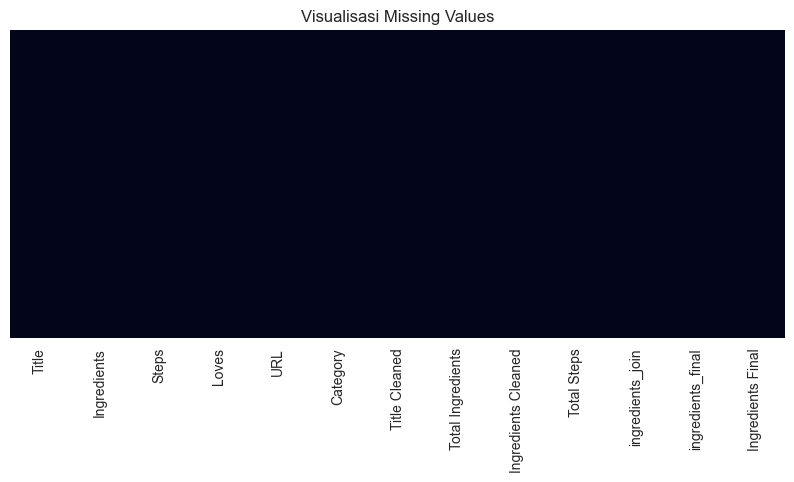

In [61]:
plt.figure(figsize=(10,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Visualisasi Missing Values")
plt.show()

Tidak ditemukan missing value pada dataset sehingga seluruh data dapat digunakan pada tahap pemodelan.

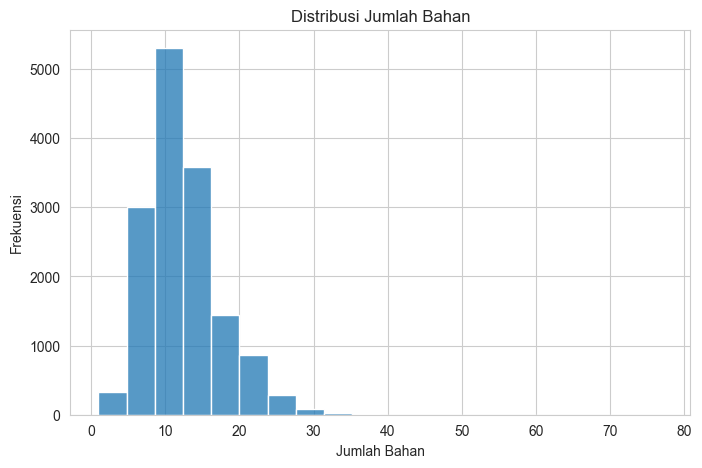

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total Ingredients"],
    bins=20
)

plt.title("Distribusi Jumlah Bahan")
plt.xlabel("Jumlah Bahan")
plt.ylabel("Frekuensi")

plt.show()

Sebagian besar resep menggunakan jumlah bahan pada rentang tertentu sehingga menunjukkan kompleksitas resep yang relatif seragam. Grafik ini menunjukkan bahwa mayoritas resep dalam dataset cenderung praktis dan tidak membutuhkan terlalu banyak komponen, dengan puncak frekuensi terbesar berada di sekitar 10 bahan per resep (mencapai lebih dari 5.000 data). Distribusinya membentuk pola condong ke kanan (right-skewed), yang mengindikasikan bahwa sementara sebagian besar resep bersifat standar dan sederhana, terdapat beberapa resep ekstrem (outliers) yang menggunakan hingga lebih dari 30 bahkan mendekati 80 bahan, yang kemungkinan merupakan masakan sangat kompleks atau akibat adanya variasi penulisan teks

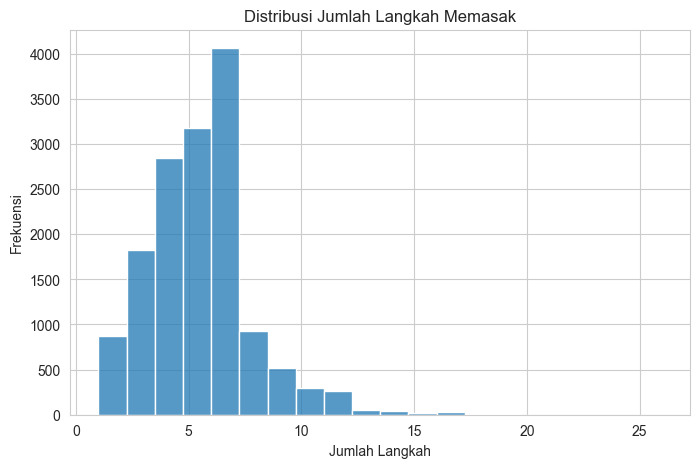

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Total Steps"],
    bins=20
)

plt.title("Distribusi Jumlah Langkah Memasak")
plt.xlabel("Jumlah Langkah")
plt.ylabel("Frekuensi")

plt.show()

Mayoritas resep memiliki jumlah langkah memasak yang tidak terlalu banyak sehingga cukup mudah diikuti pengguna. Senada dengan jumlah bahan, proses memasak dalam dataset ini juga didominasi oleh instruksi yang relatif singkat dan mudah diikuti, di mana sebagian besar resep hanya membutuhkan 5 hingga 7 langkah memasak. Pola right-skewed yang terlihat menegaskan bahwa sangat sedikit resep yang memiliki instruksi rumit hingga di atas 15 langkah. Karakteristik ini menunjukkan bahwa dataset ini sangat cocok untuk merepresentasikan profil masakan rumahan harian yang cepat dan efisien bagi masyarakat umum.

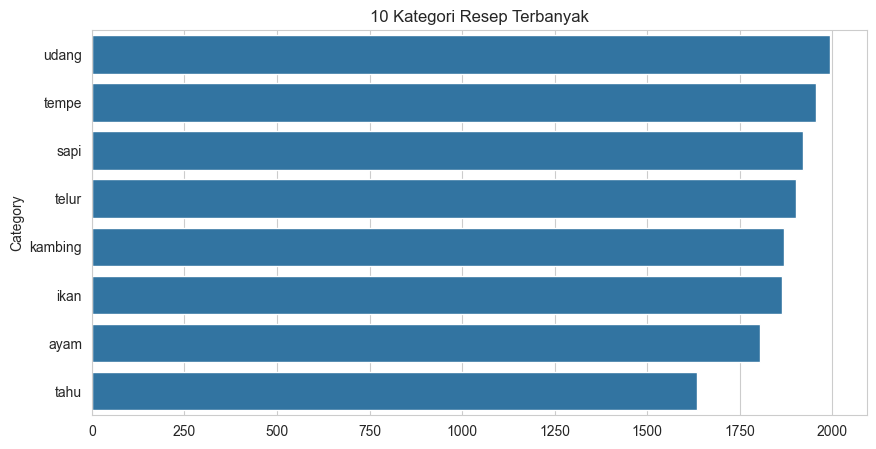

In [64]:
top_category = df["Category"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_category.values,
    y=top_category.index
)

plt.title("10 Kategori Resep Terbanyak")

plt.show()

Beberapa kategori mendominasi dataset sehingga menunjukkan jenis masakan yang paling banyak tersedia dalam kumpulan data. Visualisasi ini menunjukkan bahwa kategori resep berbasis protein laut dan nabati tradisional sangat mendominasi, dengan udang menempati posisi teratas (mendekati 2.000 resep), disusul ketat oleh tempe, sapi, dan telur. Menariknya, sebaran frekuensi antara kedelapan kategori yang tampak (dari udang hingga tahu) relatif merata dan seimbang di kisaran 1.600 hingga 2.000 resep. Keseimbangan jumlah data antar kategori (balanced dataset) seperti ini sangat menguntungkan dan siap digunakan jika Anda ingin mengembangkan model Machine Learning untuk klasifikasi resep.

In [65]:
top_loves = (
    df[["Title","Loves"]]
    .sort_values(
        by="Loves",
        ascending=False
    )
    .head(10)
)

Resep dengan nilai Loves tertinggi menunjukkan resep yang paling banyak disukai pengguna.

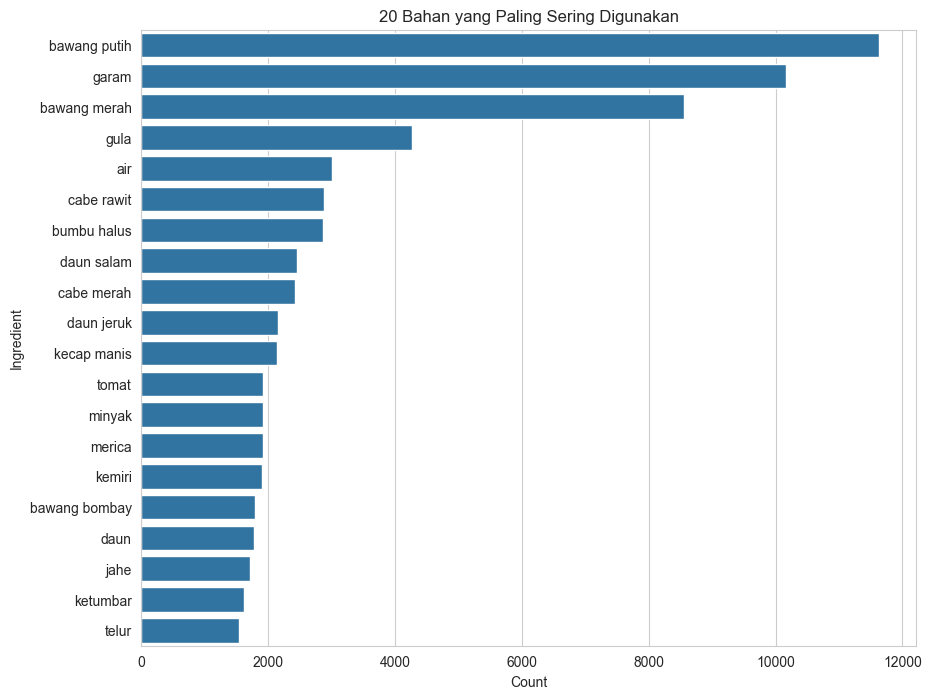

In [66]:
import ast

ingredients = (
    df["Ingredients Cleaned"]
    .apply(ast.literal_eval)
)

all_ingredients = []

for item in ingredients:
    all_ingredients.extend(item)

counter = Counter(all_ingredients)

top20 = pd.DataFrame(
    counter.most_common(20),
    columns=["Ingredient","Count"]
)

top20

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Count",
    y="Ingredient"
)

plt.title("20 Bahan yang Paling Sering Digunakan")

plt.show()

Bawang putih, garam, cabai, minyak, dan berbagai bumbu dasar merupakan bahan yang paling sering muncul pada resep masakan Indonesia. Grafik ini menegaskan karakteristik kuat dari kuliner khas Indonesia, di mana bawang putih menjadi bahan paling fundamental yang mendominasi secara mutlak (hampir 12.000 kemunculan), diikuti oleh garam dan bawang merah. Kehadiran bumbu dapur lain seperti gula, cabai rawit, bumbu halus, dan daun-daun aromatik menunjukkan profil rasa masakan yang kaya rempah, pedas, dan gurih. Namun, untuk kebutuhan analisis teks (text mining), bahan generik berfrekuensi tinggi seperti "air" dan "minyak" sebaiknya dipertimbangkan untuk dibersihkan (data cleaning) agar tidak mengaburkan keunikan rasa resep.

In [67]:
df["ingredient_length"] = (
    df["ingredients_join"]
    .str.split()
    .apply(len)
)

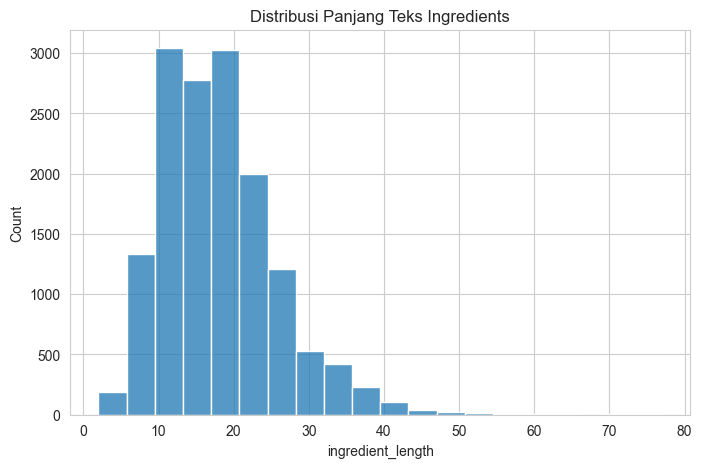

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ingredient_length"],
    bins=20
)

plt.title("Distribusi Panjang Teks Ingredients")

plt.show()

Mayoritas resep memiliki jumlah kata bahan yang relatif sedang sehingga cocok digunakan sebagai fitur teks pada metode TF-IDF. Grafik ini mengukur panjang karakter atau kata dalam penulisan string nama bahan (ingredient_length), di mana mayoritas teks ditulis secara padat dan informatif pada rentang 10 hingga 20 karakter. Konsentrasi data pada area ini menunjukkan bahwa pengguna umumnya menuliskan nama bahan secara spesifik (misalnya, menambahkan keterangan detail seperti bentuk potongan atau kondisi bahan). Adanya ekor distribusi yang memanjang hingga angka 50 ke atas menandakan adanya sebagian kecil data yang mengandung deskripsi teks terlalu panjang atau instruksi bumbu yang bercampur di dalam kolom bahan.

Kesimpulan:
Secara keseluruhan, analisis EDA terhadap dataset ini menunjukkan kualitas data yang sangat baik dan matang tanpa adanya missing value yang signifikan, sehingga siap untuk digunakan pada tahap pemodelan. Dataset ini merepresentasikan karakteristik autentik dari kuliner rumahan Indonesia, di mana sebagian besar resep bersifat praktis dengan jumlah bahan dan langkah memasak yang moderat, serta didominasi secara mutlak oleh bumbu dasar utama seperti garam, bawang putih, cabai, dan minyak. Menariknya, di samping dominasi bumbu dasar tersebut, terdapat variasi kosakata (ingredient) yang sangat kaya dan luas di dalam dataset. Kekayaan variasi tekstual ini menjadi modal kuat yang sangat ideal untuk menerapkan metode TF-IDF sebagai representasi fitur teks, guna membangun sistem rekomendasi resep berbasis konten (Content-Based Recommender System) yang akurat, relevan, dan mampu menangkap keunikan kombinasi bahan dari setiap masakan.

In [69]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Description": [
        "Nama resep asli.",
        "Daftar bahan resep sebelum preprocessing.",
        "Langkah-langkah memasak.",
        "Jumlah pengguna yang menyukai resep.",
        "URL resep asli.",
        "Kategori resep.",
        "Judul resep setelah preprocessing.",
        "Jumlah bahan dalam resep.",
        "Daftar bahan setelah preprocessing.",
        "Jumlah langkah memasak.",
        "Seluruh bahan yang telah dibersihkan dan digabung menjadi satu string untuk proses TF-IDF.",
        "Representasi bahan dalam format teks setelah preprocessing lanjutan.",
        "Daftar bahan hasil preprocessing akhir yang digunakan pada sistem rekomendasi.",
        "Jumlah kata pada fitur bahan (ingredients) untuk analisis distribusi panjang teks."
    ]
})

data_dictionary

,Column,Data Type,Description
0,Title,str,Nama resep asli.
1,Ingredients,str,Daftar bahan resep sebelum preprocessing.
2,Steps,str,Langkah-langkah memasak.
3,Loves,int64,Jumlah pengguna yang menyukai resep.
4,URL,str,URL resep asli.
5,Category,str,Kategori resep.
6,Title Cleaned,str,Judul resep setelah preprocessing.
7,Total Ingredients,int64,Jumlah bahan dalam resep.
8,Ingredients Cleaned,str,Daftar bahan setelah preprocessing.
9,Total Steps,int64,Jumlah langkah memasak.


In [70]:
data_dictionary.to_excel('data_dictionary.xlsx', index=False)
print('Data Dictionary berhasil disimpan sebagai data_dictionary.xlsx')


Data Dictionary berhasil disimpan sebagai data_dictionary.xlsx
